# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** MEHTAB AHMED

**Roll Number:** 023-24-0285

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df.shape[0])


7043


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The company wants to identify customers who are likely to leave simply that mean churn so an action could be taken to retain them and reduce customer loss
Target variable:In this data set "Churn" is target variable which indicates that whether a customer left company or stayed.

**Answer 2:**
"Columns useful for predicting of churn":
1:Internet Service:Type of internet service may affect customer satisfication and likelihood churn
2:Tech Support:customers without tech suppoort may be more likely to become dissatisfied and churn
3:Tenure:customers with shorter tenure are more likely to leaave the company
4:Monthly Charges:Higher monthly charges may increase chance of customers to leave the company
5:Contract:shorter term customers more likely to churn rather than customers having long term contracts

"Columns Useless to predict the churn "
1:Customer ID:it is just a unique identifier for customer does not show or tell any info that helps predicting the churn
2:Gender:it has very less influence on churn 

**Answer 3:**
Q1:Does paying higher monthly charges increase chance of customer churning?
Q2:which customers more likely to churn Shorter term contracts or longer contracts?


---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [5]:
# Task 4 — dataset shape, column names, data types
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")
print("Number of customers : ",df.shape[0])
print("Number of Features : ",df.shape[1])

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical Features:")
print(list(numerical_features))


categorical_features = df.select_dtypes(include=['object']).columns

print("\nCategorical Features:")
print(list(categorical_features))

Number of customers :  7043
Number of Features :  21

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\SINDH\AppData\Local\Temp\ipykernel_13160\655835348.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [ ]:
# Task 5 — identify identifier columns / wrong data types
1:CustomerID: it is an identifier ans should not be used as predictive feature
2:TotalCharges:it has incorrect datatype because it represnets numerical charges but may be
stored as text

In [9]:
# Task 6 — unique values in 3 categorical columns

print("Gender:", df["gender"].unique())
print("InternetService:", df["InternetService"].unique())
print("Contract:", df["Contract"].unique())

Gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Contract: <ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str


**Observations (Part 2):**
This dataset contains 7043 customers and 21 columns,four of them are numerical features while remaining are mainly catogorical.
CustomerId is an identifier rather than a useful predictive feature,and TotalCharges appeared to have wrong because it represents numerical charges but may be stored as text.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [23]:
# # Task 7 — missing values: count and percentage per column
print("Missing Values per column : \n",df.isnull().sum())
print("\nMissing Percentage :\n",df.isnull().sum()/len(df)*100)


Missing Values per column : 
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing Percentage :
 customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract        

In [24]:
# Task 8 — duplicate rows vs duplicate IDs

print("Duplicate rows:", df.duplicated().sum())

# Check duplicate customer IDs
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())


Duplicate rows: 0
Duplicate customer IDs: 0


In [28]:
# Task 9 — investigate a suspicious / invalid value
print(df["SeniorCitizen"].unique())


[0 1]


**Answer 7 (which missing-value problems need action, and why):**
The missing value in TotalCharges require action becaue it contains the total amount paid by 
customer,so missing values can affect calculations and analysis.Columns with no missing values do
not require any action because the have complete data

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
Duplicate rows and duplicate customer IDs are different issues. Duplicate rows mean the
complete record is repeated, while duplicate customer IDs mean the same customer may 
have more than one record.Both should be checked because they can affect the accuracy of the
analysis.


**Answer 9 (suspicious value found and how):**
found that SeniorCitizen contains values 0 and 1 instead of clear labels like Yes and No. I found this by checking its unique values. The values are not invalid, but they are less clear and may need to be interpreted correctly.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

Problem: TotalCharges contains blank values and  as text.

Decision: Convert it to numerical and handle the missing values.

Method Used: Replace blank spaces with NaN and convert the column to numeric.

Reason: TotalCharges represents the total amount paid, so it should be numerical and missing values can affect analysis.


In [6]:
# Task 11 — apply your cleaning decisions here
# Replace blank spaces with missing values
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

# TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

#for conformation datatype datatype of "TotalCharges"
print(df["TotalCharges"].dtype)

#blank values are now recognized as missing
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())



float64
Missing TotalCharges: 11


In [7]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Check duplicate customer IDs
print("\nDuplicate customer IDs:")
print(df["customerID"].duplicated().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Duplicate rows:
0

Duplicate customer IDs:
0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract 

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

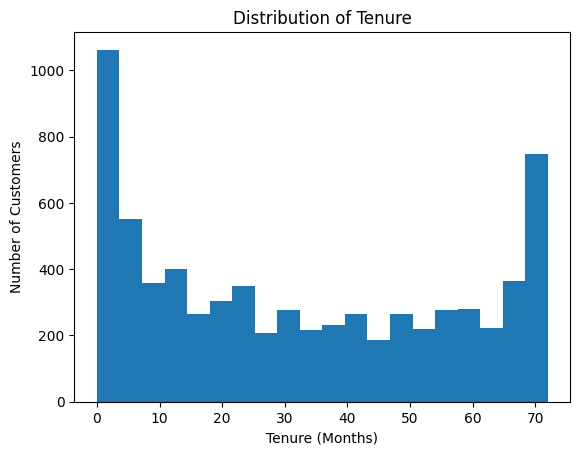

In [8]:
# Task 12 — numerical feature 1: distribution plot
import matplotlib.pyplot as plt

df["tenure"].plot(kind="hist", bins=20)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()




**Observation:** _(what did you learn from this chart?)_
TENURE
Most customers have relatively short to medium tenure, while fewer customers have very long tenure. This shows that the dataset contains customers with different lengths of time with the company.






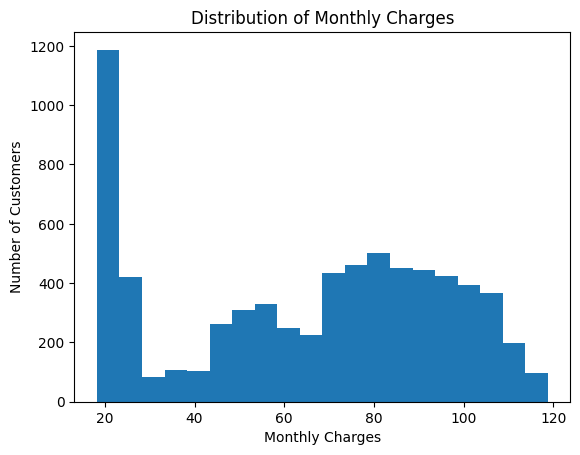

In [37]:
# Task 12 — numerical feature 2: distribution 

df["MonthlyCharges"].plot(kind="hist", bins=20)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()


**Observation:** _(what did you learn from this chart?)_
Monthly charges are spread across different price levels, with many customers paying moderate monthly charges. There are fewer customers at the very low and very high charge levels

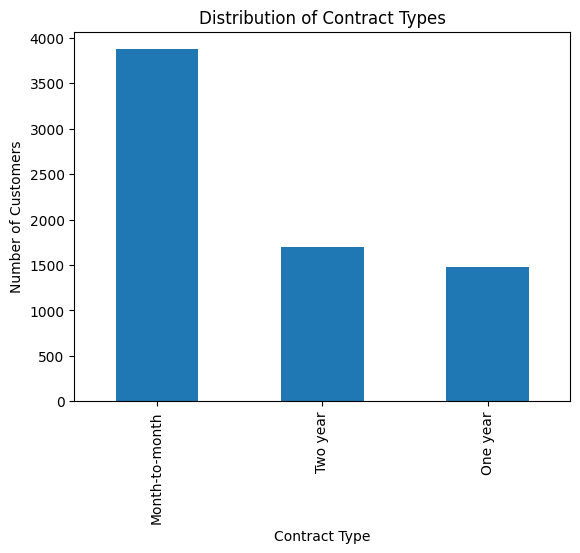

In [38]:
# Task 12 — categorical feature 1: distribution plot
df["Contract"].value_counts().plot(kind="bar")
plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _(what did you learn from this chart?)_
Most customers have month-to-month contracts, while fewer customers have one-year or two-year contracts. This shows that short-term contracts are more common in the dataset.

In [ ]:
# Task 12 — categorical feature 2: distribution plot
df["InternetService"].value_counts().plot(kind="bar")
plt.title("Distribution of Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _(what did you learn from this chart?)_
iber optic and DSL are the main internet services used by customers, while some customers do not have internet service. The number of customers differs between the service type

**Answer 13 (outliers / skew and possible explanation):**
tenure is somewhat unevenly distributed, with more customers having shorter or medium tenure and fewer customers having very long tenure. MonthlyCharges also has some higher values compared with most customers, which may be because some customers use more expensive internet or additional services.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [40]:
# Task 14 — churn counts and percentages
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
The dataset has 1,869 churned customers (26.5%) and 5,174 non-churned customers (73.5%). Therefore, the target variable is imbalanced because there are significantly more non-churned customers than churned customers.

**Answer 15 (why imbalance might matter later):**
Class imbalance matters because the model may become biased toward the larger class, which is non-churned customers in this dataset. As a result, the model may predict that customers will not churn most of the time and still get high accuracy, while performing poorly at identifying customers who actually churn.


---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [42]:
# Task 16 — categorical feature 1 vs Churn
pd.crosstab(df["Contract"], df["Churn"])
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**Observation:**:Month-to-month customers appear to churn more often than customers with one-year or two-year contracts.
**Evidence:** The Contract categories show a noticeably higher proportion of Churn = Yes for month-to-month customers
**Possible Explanation:** Month-to-month customers have less commitment, so they can leave the company more easily.

In [44]:
# Task 16 — categorical feature 2 vs Churn

pd.crosstab(df["InternetService"], df["Churn"])
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


**Observation:** Customers with Fiber optic internet appear to have a higher churn rate than customers with DSL or no internet service.
**Evidence:** When InternetService is compared with Churn, the proportion of Churn = Yes is higher for Fiber optic customers.
**Possible Explanation:** Fiber optic customers may have higher charges or may experience service-related dissatisfaction, which could make them more likely to leave.

In [45]:
# Task 17 — numerical feature 1 vs Churn
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

**Observation:** Customers who churn generally have lower tenure than customers who stay.
**Evidence:** The average tenure for Churn = Yes is lower than the average tenure for Churn = No
**Possible Explanation:** Newer customers may not be strongly attached to the company and may leave more easil

In [47]:
# Task 17 — numerical feature 2 vs Churn
df.groupby("Churn")["MonthlyCharges"].mean()


Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

**Observation:** Customers who churn generally have higher monthly charges than customers who stay
**Evidence:** The average MonthlyCharges for Churn = Yes is higher than the average for Churn = No.
**Possible Explanation:** Customers paying higher monthly charges may feel that the service is too expensive and may decide to leave.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102411
tenure               0.016567  1.000000        0.247900      0.825880
MonthlyCharges       0.220173  0.247900        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


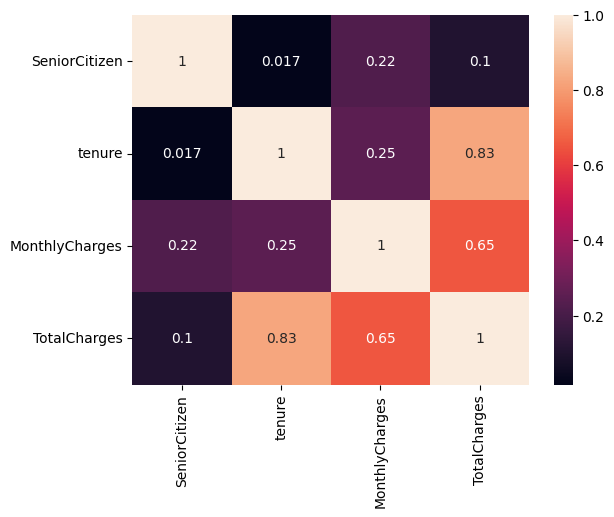

In [49]:
# Task 18 — correlation matrix and heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
print(corr)
sns.heatmap(corr, annot=True)
plt.show()


**Answer 18 (most correlated pairs):**
The pair that appears most correlated is tenure and TotalCharges. They have a strong positive correlation, meaning customers with longer tenure generally have higher total charges


**Answer 19 (correlation vs. causation; potential problems):**
Correlation does not mean causation, so the correlation between tenure and TotalCharges does not mean that one causes the other. However, highly correlated features can cause problems for some models because they may provide similar information and make the model harder to understand

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
customerID is a purely identifying column and should not be used as a predictive feature. I did not find another column that clearly contains information only known after the customer has churned, so there is no obvious data leakage apart from the identifier issue.

**Answer 21 (what would go wrong):**
If an identifier or data-leakage column is included in the model, the model may learn information that does not actually help predict future churn.Churn is target variable and should not be used as input feature.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|--------|------|------|--------|--------|
| customerID | Identifier | Identifier | Remove | Only identifies customers and does not help predict churn. |
| gender | Categorical | Feature | Keep | May help predict churn. |
| SeniorCitizen | Numerical (Binary) | Feature | Keep | Valid 0/1 values and may influence churn. |
| Partner | Categorical | Feature | Keep | May affect customer churn. |
| Dependents | Categorical | Feature | Keep | May affect customer churn. |
| tenure | Numerical | Feature | Keep | Important predictor of churn. |
| PhoneService | Categorical | Feature | Keep | Describes customer service usage. |
| MultipleLines | Categorical | Feature | Keep | May influence churn. |
| InternetService | Categorical | Feature | Keep | Important customer service information. |
| OnlineSecurity | Categorical | Feature | Keep | May affect customer retention. |
| OnlineBackup | Categorical | Feature | Keep | May affect churn. |
| DeviceProtection | Categorical | Feature | Keep | May influence churn. |
| TechSupport | Categorical | Feature | Keep | May influence churn. |
| StreamingTV | Categorical | Feature | Keep | Customer service information. |
| StreamingMovies | Categorical | Feature | Keep | Customer service information. |
| Contract | Categorical | Feature | Keep | One of the strongest predictors of churn. |
| PaperlessBilling | Categorical | Feature | Keep | May influence churn. |
| PaymentMethod | Categorical | Feature | Keep | May be related to customer behavior. |
| MonthlyCharges | Numerical | Feature | Keep | Important numerical predictor. |
| TotalCharges | Numerical | Feature | Keep (Cleaned) | Converted from text to numeric and missing values handled. |
| Churn | Categorical | Target | Keep | Target variable to be predicted. |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [67]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

clean_df = clean_df.drop_duplicates()
print("Duplicates in clean_df:", clean_df.duplicated().sum())
df.duplicated().sum()
clean_df.to_csv("clean_churn.csv", index=False)
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)


Duplicates in clean_df: 0


In [68]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("DATASET INFO:")
clean_df.info()

print("\nMISSING VALUES:")
print(clean_df.isnull().sum())

print("\nDUPLICATE ROWS:")
print(clean_df.duplicated().sum())

DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str  

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: Most customers do not churn.
- Evidence: 73.5% of customers are non-churned, while 26.5% are churned.
- Interpretation: he company keeps most of its customers, but churn is still important because about one-fourth of customers leave.

**Finding 2**
- Observation:Customers with month-to-month contracts are more likely to churn. 
- Evidence: The Contract vs Churn comparison shows a higher churn percentage for month-to-month customers.
- Interpretation: Customers with shorter contracts may have less commitment and can leave more easily.

**Finding 3**
- Observation:Customers who churn generally have lower tenure 
- Evidence: The average tenure for churned customers is lower than for non-churned customers.
- Interpretation: Newer customers may be more likely to leave because they have not been with the company for a long time.

**Finding 4**
- Observation:tenure and TotalCharges are strongly related. 
- Evidence: The correlation matrix shows that tenure and TotalCharges have the strongest positive correlation.
- Interpretation: Customers who stay longer generally accumulate higher total charges

**Finding 5**
- Observation: TotalCharges needed data cleaning
- Evidence:The column was originally stored as text and contained 11 blank/missing values.
- Interpretation: The column needed to be converted to a numerical type and the missing values needed to be handled before further analysis or modeling.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   The most important data-quality issue I found was TotalCharges being stored as text and containing 11 missing values. This needed to be converted to a numerical type and the missing values needed to be handled before analysis and modeling.
2. What was the most interesting pattern you discovered?
   The most interesting pattern I discovered was that month-to-month contract customers had a much higher churn rate than customers with one-year or two-year contracts. This suggests that customers with shorter contracts may be more likely to leave the company
3. Which feature seems most useful for predicting churn?
   Contract seems to be one of the most useful features for predicting churn. Month-to-month customers showed a much higher churn rate compared with customers on one-year or two-year contracts.
4. Which feature should probably not be used, and why?
   customerID should probably not be used because it is only an identifier for each customer and does not provide useful information about their behavior or likelihood of churning.
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   efore ML modeling, I will need to handle missing values, convert categorical features into numerical form, and remove customerID because it is only an identifier. Numerical features may also need to be scaled depending on the model being used.
6. What would you do next if you had another 3 hours?
 I would definetly take a cup a tea and rest for 3 hours or read a book on "How to choose your degree wisely"


---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [1 ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [1] A working `clean_df`, saved as `clean_churn.csv`
- [1] A completed ML-readiness table (Part 10) covering every column
- [1] Five Key Findings written (Part 12)
- [1] Answered all six Final Reflection questions
- [1] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [1] Added your GitHub repository link at the top of this notebook